<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


In [1]:
FULLNAME = 'Mohammad MohammadianBisheh '
STD_ID = '401110342'

In this notebook, we aim to perform **classification** on images from the **CIFAR10** dataset using CNN networks. First, we load the dataset and apply the necessary transformations for normalization and augmentation. After that, we visualize some samples. Once we familiarize ourselves with the dataset, we proceed to design the desired convolutional network, which is explained in the relevant section. After designing the model, we move on to training and evaluating it. At the end of the first section, we analyze the feature space from different perspectives. First, using the KNN method, we examine the closest samples to each other in the feature space. Then, we cluster the data and finally visualize the outputs of the intermediate layers of the model.

In the second part of the notebook, we perform a simple transfer learning task on the trained model from the first section but using a new dataset, **CIFAR100**. To do this, we modify the final layer of the network and retrain it. Further details are provided in the relevant section. Finally, we evaluate the model’s accuracy on the new task and analyze the extracted features and how well the model generalizes. After designing and training the model, we will further analyze the extracted feature space. Finally, we will evaluate the generalization ability of the model and its extracted features on a new dataset,

# CIFAR10 Classification

## Import Libraries

Import needed libraries

In [2]:
!pip install --upgrade pip
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import tqdm
from time import time
import random
from sklearn.manifold import TSNE
import numpy as np
from random import sample
import math
import torch.optim as optim
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


## Device

Set device to work with (GPU or CPU)

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [4]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
# TODO: Data Transforms

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# TODO: Load Train Data
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform_train)

# TODO: Split Train and Validation Data
train_size = int(0.9 * len(full_trainset))
val_size = len(full_trainset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_trainset, [train_size, val_size])


# TODO: Load Test Data
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)


# TODO: Define Data Loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

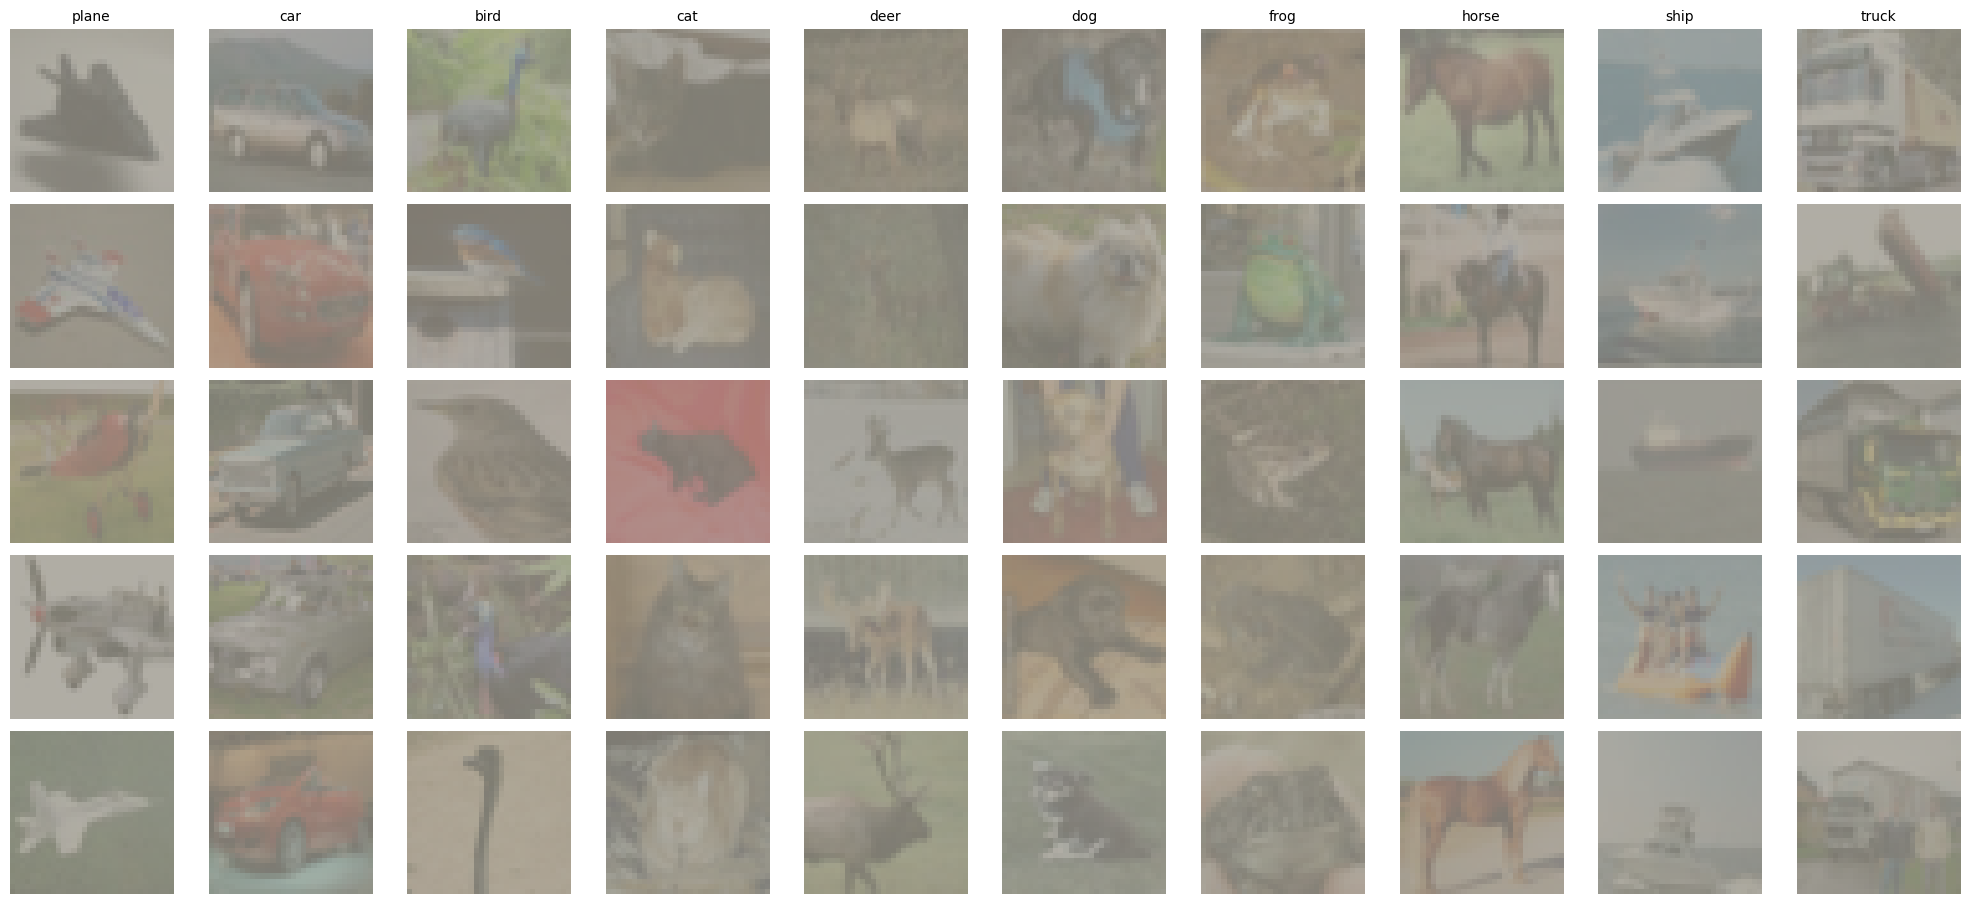

In [6]:
# TODO: Find 5 Images from Each Class
num_per_class = 5
class_to_images = {cls: [] for cls in range(10)}

# We'll use the original (non-augmented) images for visualization
vis_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transforms.ToTensor())

for img, label in vis_dataset:
    if len(class_to_images[label]) < num_per_class:
        class_to_images[label].append(img)
    if all(len(imgs) == num_per_class for imgs in class_to_images.values()):
        break

# Plot Images
fig, axes = plt.subplots(num_per_class, 10, figsize=(20, 10))


for class_idx in range(10):
    for i in range(num_per_class):
        ax = axes[i, class_idx]
        img = class_to_images[class_idx][i]
        img = img.permute(1, 2, 0).numpy()  # CxHxW to HxWxC
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img = img * std + mean  # De-normalize
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis('off')
        if i == 0:
            ax.set_title(classes[class_idx], fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

- **Hint I**: Our goal is to get accuracy above *90%* on testset. Our suggestion is to implement ResNet (ResNet18 could be a viable choice)
  - You can learn the network's structure and implementation online (Youtube, ...) and then implmenet it yourself and make changes to enhance it's performance on our task **(YOU SHOULD NOT COPY THE CODE!!! OTHERWISE, YOU'LL BE PENALIZED!!!)**

- **Hint II**: When defining your model, pay attension to the **NOTICE** part in the above. It's also better to read the "Exploring the feature space" section beforehand.  

In [7]:
# TODO: Implement Model
feature_dim = 256
class MyCNN(nn.Module):
    def __init__(self, feature_dim):
        super(MyCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 16x16
            nn.Dropout(0.25)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 8x8
            nn.Dropout(0.3)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),  # 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 4x4
            nn.Dropout(0.35)
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),  # 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 2x2
            nn.Dropout(0.4)
        )

        # Rename this layer so hook can access it
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # Feature space layer (N > 10)
        self.fc_feature = nn.Linear(512, feature_dim)

        # Output classification layer
        self.fc_output = nn.Linear(feature_dim, 10)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # Flatten to (batch_size, 512)

        features = self.fc_feature(x)  # Feature vector (for visualization later)
        out = self.fc_output(features)  # Final output logits for 10 classes
        return out, features


## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [8]:
# TODO: Define Model
model = MyCNN(feature_dim).to(device)

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [9]:
# TODO: Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

### Train loop

Train your model

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage

In [10]:
# TODO: Implement Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    bar = tqdm.tqdm(dataloader, desc='', leave=False)

    for inputs, labels in bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        avg_loss = running_loss / total
        acc = 100 * correct / total
        bar.set_description(f"Loss: {avg_loss:.3e} - Acc: {acc:.2f}%")

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = 100 * correct / len(dataloader.dataset)
    return epoch_loss, epoch_acc


In [11]:
# TODO: Implement Validation Loop
def validate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    bar = tqdm.tqdm(dataloader, desc='', leave=False)

    with torch.no_grad():
        for inputs, labels in bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            avg_loss = running_loss / total
            acc = 100 * correct / total
            bar.set_description(f"Loss: {avg_loss:.3e} - Acc: {acc:.2f}%")

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = 100 * correct / len(dataloader.dataset)
    return epoch_loss, epoch_acc


In [12]:
# TODO: Train The Model
num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    start_time = time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step()

    end_time = time()
    print(f"Epoch {epoch+1:>3} finished in {end_time - start_time:.2f}s - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%\n")

print("FEATURE DIM : " , feature_dim)

Epoch   1 finished in 36.35s - Train Loss: 1.4407 - Train Acc: 46.76% - Val Loss: 1.1487 - Val Acc: 59.50%



Epoch   2 finished in 24.56s - Train Loss: 1.0141 - Train Acc: 63.94% - Val Loss: 1.0612 - Val Acc: 64.50%



Epoch   3 finished in 24.41s - Train Loss: 0.8349 - Train Acc: 70.72% - Val Loss: 0.7322 - Val Acc: 74.40%



Epoch   4 finished in 24.89s - Train Loss: 0.7384 - Train Acc: 74.42% - Val Loss: 0.8565 - Val Acc: 71.94%



Epoch   5 finished in 24.60s - Train Loss: 0.6615 - Train Acc: 77.17% - Val Loss: 0.6323 - Val Acc: 77.64%



...

Epoch  46 finished in 25.08s - Train Loss: 0.1522 - Train Acc: 94.59% - Val Loss: 0.2883 - Val Acc: 91.08%



Epoch  47 finished in 27.34s - Train Loss: 0.1489 - Train Acc: 94.74% - Val Loss: 0.2870 - Val Acc: 91.12%



Epoch  48 finished in 25.13s - Train Loss: 0.1521 - Train Acc: 94.66% - Val Loss: 0.2942 - Val Acc: 90.92%



Epoch  49 finished in 33.37s - Train Loss: 0.1455 - Train Acc: 94.90% - Val Loss: 0.2908 - Val Acc: 91.18%



Epoch  50 finished in 24.93s - Train Loss: 0.1482 - Train Acc: 94.84% - Val Loss: 0.2898 - Val Acc: 90.94%

FEATURE DIM :  256


### Save Model

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [13]:
# TODO: Save Model
torch.save(model.state_dict(), 'net.pth')

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

FEATURE DIM :  256


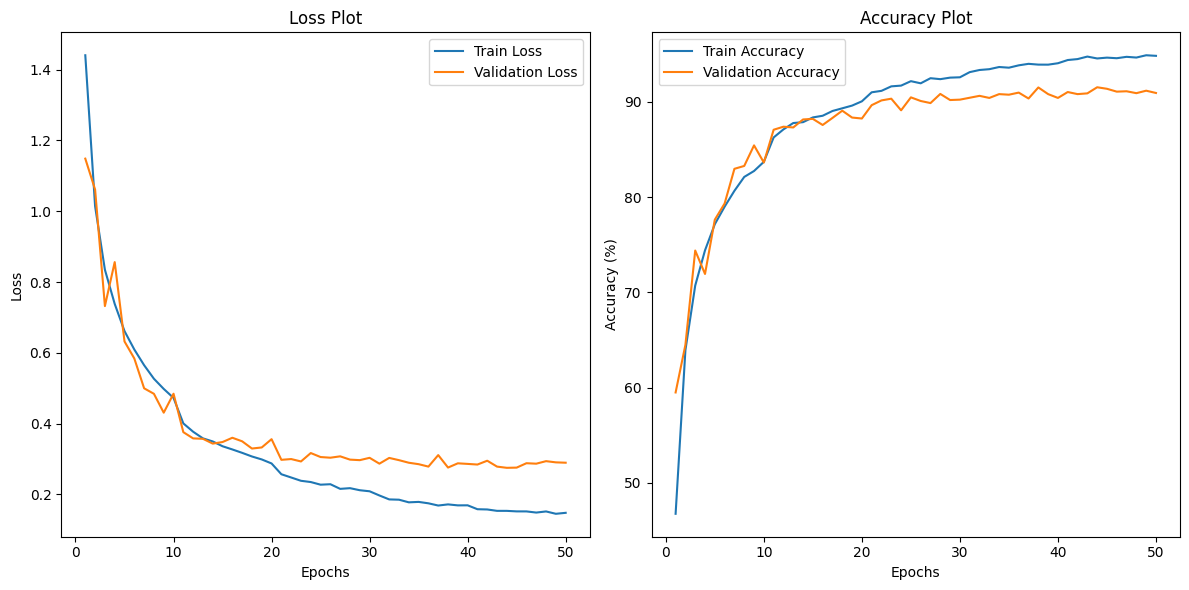

In [14]:
# TODO: Plot Loss
print("FEATURE DIM : " , feature_dim)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss Plot')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# TODO: Plot Accuracy

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()


plt.tight_layout()
plt.show()


## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `90%`

In [15]:
# TODO: Run Model on Testset
val_loss, test_acc = validate(model, val_loader, criterion)
print(f'Accuracy on test set: {test_acc:.2f}%')

Accuracy on test set: 91.56%


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

FEATURE DIM :  256


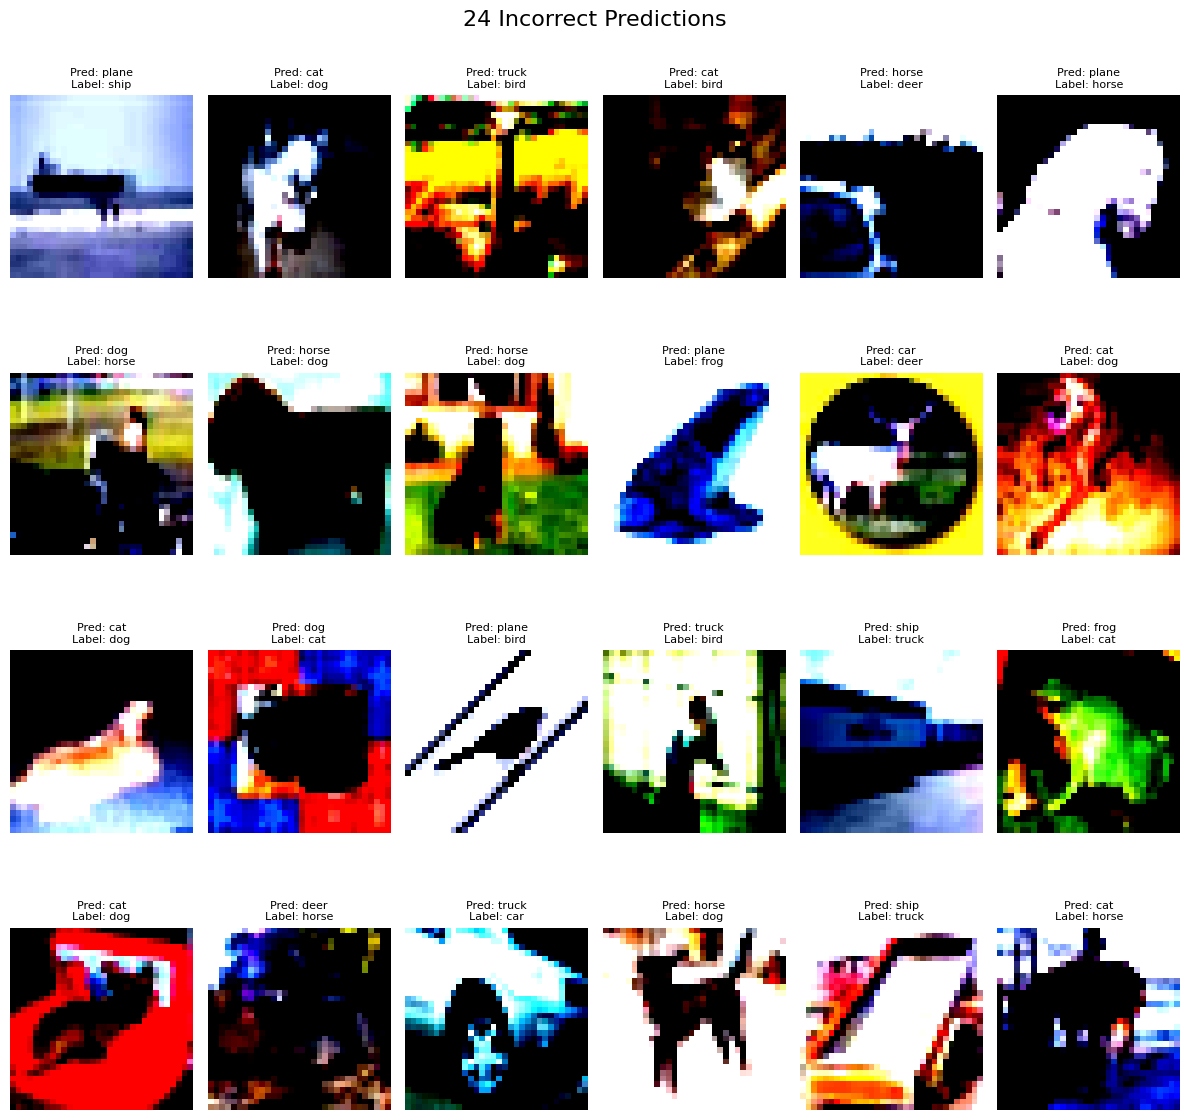

In [16]:
# TODO: Plot Samples with Wrong Predicted Classes
incorrect_samples = []
print("FEATURE DIM : " , feature_dim)
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs, _ = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Find indices where prediction != label
        incorrect_mask = preds != labels
        incorrect_inputs = inputs[incorrect_mask]
        incorrect_preds = preds[incorrect_mask]
        incorrect_labels = labels[incorrect_mask]

        for img, pred, label in zip(incorrect_inputs, incorrect_preds, incorrect_labels):
            incorrect_samples.append((img.cpu(), pred.cpu(), label.cpu()))
random.shuffle(incorrect_samples)
incorrect_samples = incorrect_samples[:24]
# print("FEATURE DIM : " , feature_dim)

# Plotting
plt.figure(figsize=(12, 12))
for i, (img, pred, label) in enumerate(incorrect_samples):
    #img = img * std + mean  # unnormalize
    img = img.permute(1, 2, 0).numpy()  # CHW to HWC

    plt.subplot(4, 6, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Pred: {classes[pred.item()]}\nLabel: {classes[label.item()]}", fontsize=8)
    plt.axis('off')

plt.suptitle("24 Incorrect Predictions", fontsize=16)
plt.tight_layout()
plt.show()

## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(50000, N)` saved in a variable (for later usage)

- **Hint 1:** define a tensor with dimension `(50000, N)` where *50000* is the size of the trainset and *N* is the dimension of the feature space

- **Hint 2:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [17]:
# TODO: Find Features and Put Them in One Dimensional List
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

train_features = torch.zeros(50000, feature_dim)
print("Feature dimension:", feature_dim)

# Container to collect batch-wise features
feature_list = []

# Hook function to capture output from a specific layer (e.g., avgpool)
def hook_fn(module, input, output):
    feature_list.append(output.detach().cpu())

# Register the hook on the model's feature layer
# Register the hook on the model's fc_feature layer (not avgpool)
hook = model.fc_feature.register_forward_hook(hook_fn)

# Extract features without updating gradients
model.eval()
with torch.no_grad():
    for inputs, _ in tqdm.tqdm(train_loader, desc="Extracting Features via Hook"):
        inputs = inputs.to(device)
        _ = model(inputs)  # Forward pass triggers the hook

# Remove the hook after use
hook.remove()

# Concatenate all features and reshape
features = torch.cat(feature_list, dim=0)
features = features.view(features.size(0), -1)
print("Extracted train_features shape:", train_features.shape)
# Copy into the final train_features tensor
train_features[:features.size(0)] = features

# Final check
print("Extracted train_features shape:", train_features.shape)


Feature dimension: 256


Extracting Features via Hook: 100%|██████████| 704/704 [00:25<00:00, 28.07it/s]

Extracted train_features shape: torch.Size([50000, 256])
Extracted train_features shape: torch.Size([50000, 256])


### K Nearest Neighbor in feature space

You already have calculated the feature spaces for trainset ($S$) in the previous section

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

**Note:** Your visualization should be something like the below picture

**Hint:** To find the nearest neighbors in the feature space, you can use any library of your choice.

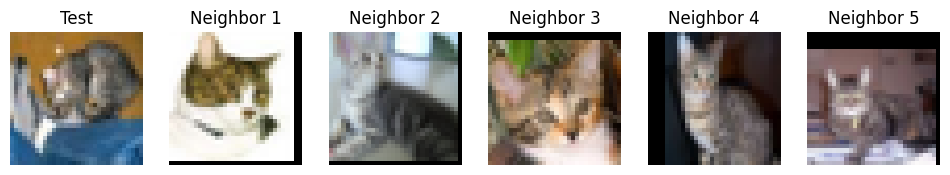

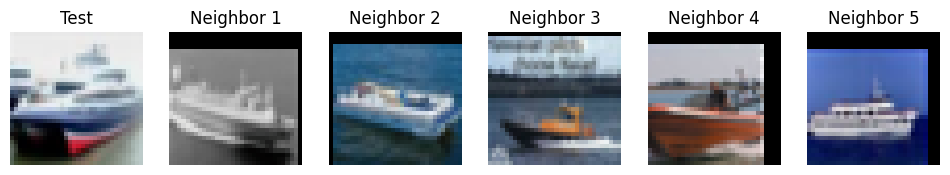

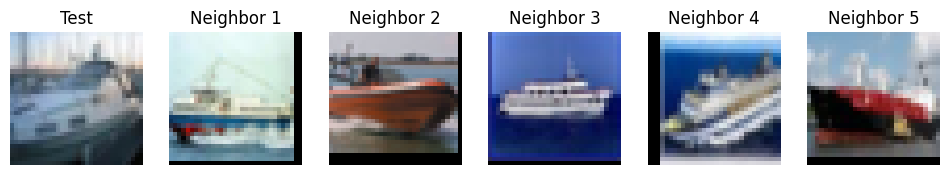

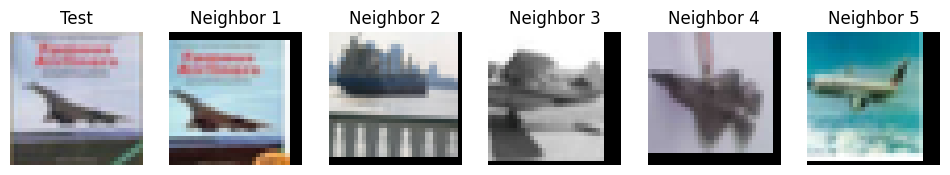

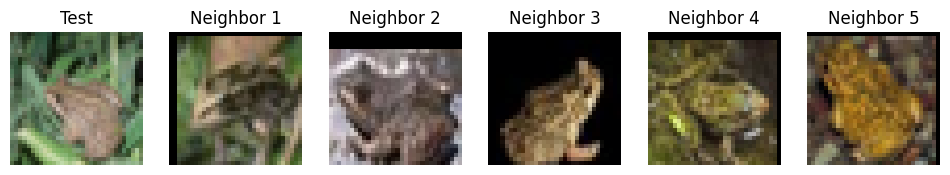

In [18]:
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt

# === Extract features from 2000 training samples ===
feature_list_train = []

def hook_fn_train(module, input, output):
    feature_list_train.append(output.view(output.size(0), -1).detach().cpu())

hook_train = model.avgpool.register_forward_hook(hook_fn_train)

model.eval()
with torch.no_grad():
    for i, (inputs, _) in enumerate(train_loader):
        inputs = inputs.to(device)
        model(inputs)
        if len(feature_list_train) * inputs.size(0) >= 2000:
            break

hook_train.remove()
features_train = torch.cat(feature_list_train, dim=0)  # (2000, feature_dim)

# === Get 5 correctly predicted test samples ===
correct_test_samples = []
correct_test_features = []

feature_list_test = []

def hook_fn_test(module, input, output):
    feature_list_test.append(output.view(output.size(0), -1).detach().cpu())

hook_test = model.avgpool.register_forward_hook(hook_fn_test)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs, _ = model(inputs)
        preds = outputs.argmax(dim=1)
        features = feature_list_test[-1]

        for i in range(inputs.size(0)):
            if preds[i] == labels[i]:
                correct_test_samples.append(inputs[i].cpu())
                correct_test_features.append(features[i])
                if len(correct_test_samples) == 5:
                    break
        if len(correct_test_samples) == 5:
            break

hook_test.remove()
correct_test_features = torch.stack(correct_test_features, dim=0)

# === Plot each test sample and its 5 nearest neighbors ===
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def unnormalize(img):
    return torch.clamp(img * std + mean, 0, 1)

for i in range(5):
    test_feat = correct_test_features[i].unsqueeze(0).numpy()
    distances = cosine_distances(test_feat, features_train.numpy())
    neighbor_indices = distances.squeeze().argsort()[:5]

    plt.figure(figsize=(12, 2))
    for j in range(6):
        plt.subplot(1, 6, j + 1)
        if j == 0:
            img = unnormalize(correct_test_samples[i])
            plt.title("Test")
        else:
            train_img, _ = train_loader.dataset[neighbor_indices[j - 1]]
            img = unnormalize(train_img)
            plt.title(f"Neighbor {j}")
        plt.imshow(img.permute(1, 2, 0).numpy())
        plt.axis('off')
    plt.show()


### TSNE

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now you a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)
4. Print the shape of the output

**Hint:** You can use `sklearn.manifold.TSNE`

In [19]:
from sklearn.manifold import TSNE
# TODO: Get Samples
M = 2000
indices = np.random.choice(len(train_loader.dataset), M, replace=False)  # Randomly select indices
sampled_features = train_features[indices]
print(len(train_loader.dataset))
# TODO: Use TSNE
tsne = TSNE(n_components=2, random_state=42)
reduced_features = tsne.fit_transform(sampled_features)

45000


Visualize the points in a 2D plane (Set color of each point based on it's class)

**Notice:** Your visualization should be something like the below image

**Hint:** Use `plt.scatter(x, y, c=labels)`

10
['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


<ipython-input-20-8c28e5c89c12>:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(classes))


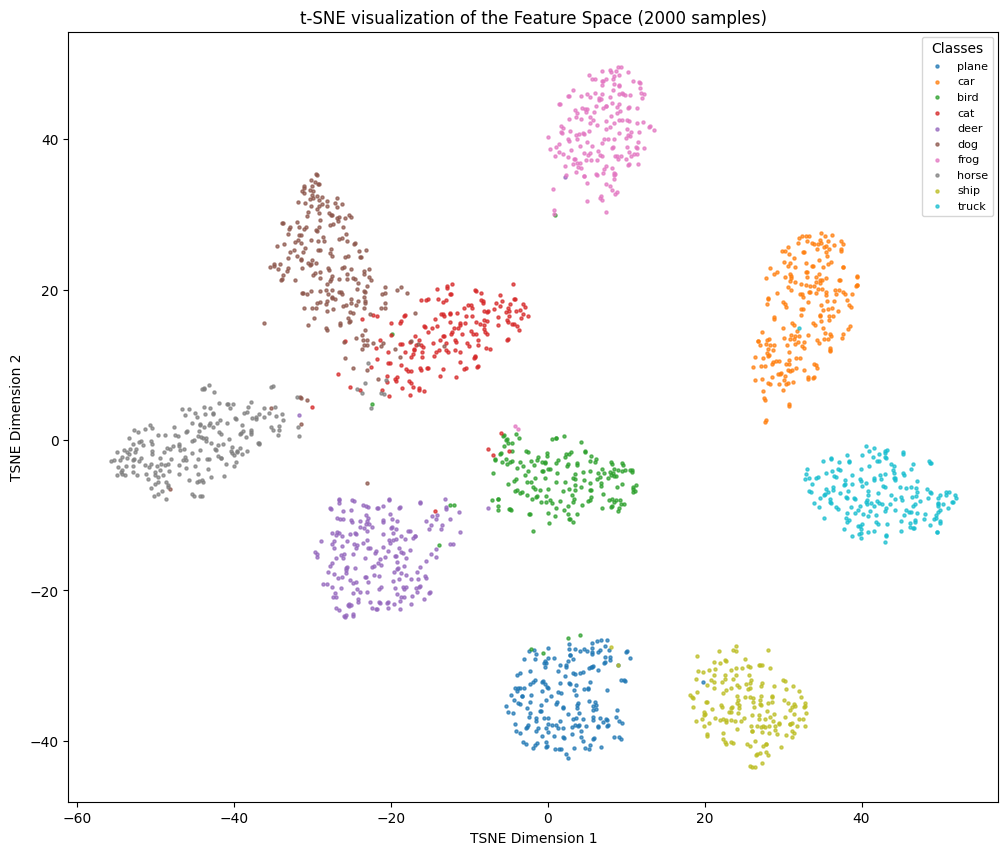

In [20]:
# TODO: Plot Results

# Get the subset of labels corresponding to the randomly selected indices
train_labels_subset = [train_loader.dataset[idx][1] for idx in indices]  # List comprehension to get the labels

# Convert the list of labels into a tensor
train_labels_subset = torch.tensor(train_labels_subset)

print(len(classes))
print(classes)
# Now plot the t-SNE results
plt.figure(figsize=(12, 10))

# Set up color mapping for each class
colors = plt.cm.get_cmap('tab10', len(classes))

# Plot each class
for i in range(len(classes)):
    # Get indices of samples belonging to the current class
    class_indices = (train_labels_subset == i)
    # Plot the samples for this class
    plt.scatter(reduced_features[class_indices, 0], reduced_features[class_indices, 1],
                label=classes[i],
                s=5, alpha=0.7, color=colors(i))

# Add legend to indicate which color corresponds to which class
plt.legend(title="Classes", loc="upper right", fontsize=8)
plt.title("t-SNE visualization of the Feature Space (2000 samples)")
plt.xlabel("TSNE Dimension 1")
plt.ylabel("TSNE Dimension 2")
plt.show()


### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

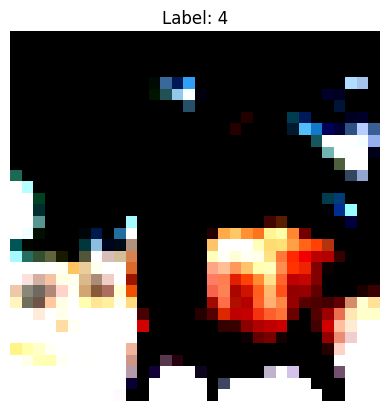

In [21]:
# TODO: Select an Image

import random

# Get a random index
idx = random.randint(0, len(train_dataset) - 1)

# Get the image and label
img, label = train_dataset[idx]

# Unsqueeze to add batch dimension
input_img = img.unsqueeze(0).to(device)

# Show the image
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children()[:2])
)
intermediate_output = clipped(input)
```



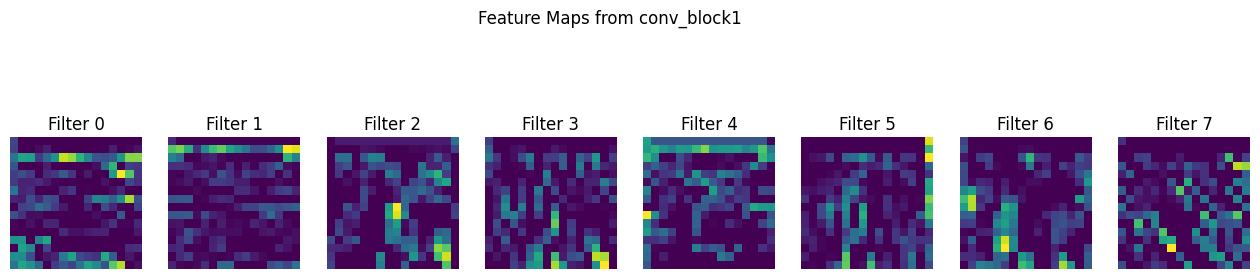

In [22]:
# TODO: Get Intermediate Output

clipped = nn.Sequential(
    model.conv_block1
)

# Set model to eval mode and pass the image through the clipped part
clipped.eval()
with torch.no_grad():
    intermediate_output = clipped(input_img)

# Plot the first 8 feature maps
plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(intermediate_output[0, i].cpu(), cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i}')
plt.suptitle('Feature Maps from conv_block1')
plt.show()

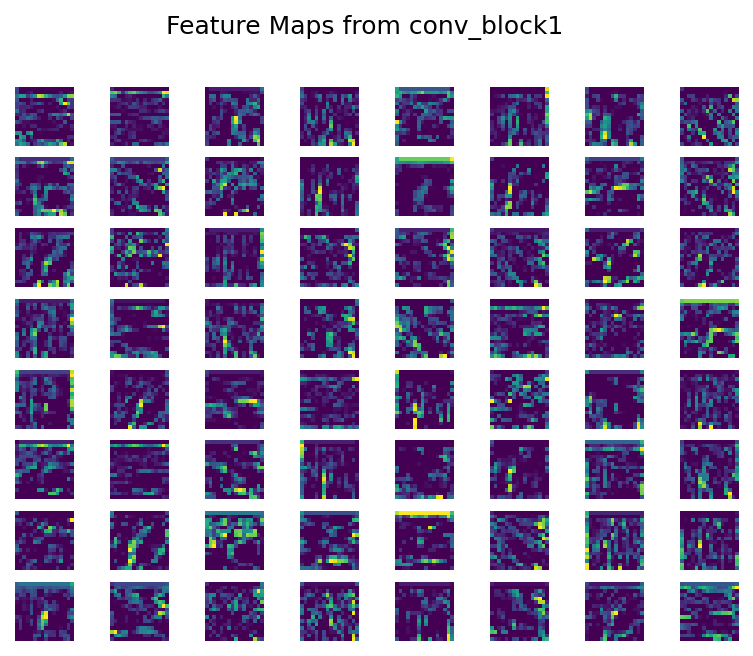

In [23]:
def plot_intermediate_output(result, title=None):
    """ Plots the intermediate output of shape
      N_FILTERS x H x W
    """
    plt.rcParams['figure.dpi'] = 150
    n_filters = result.shape[1]
    N = int(math.sqrt(n_filters))
    M = (n_filters + N - 1) // N
    assert N * M >= n_filters

    fig, axs = plt.subplots(N, M)
    fig.suptitle(title)

    for i in range(N):
        for j in range(M):
            if i*N + j < n_filters:
                axs[i][j].imshow(result[0, i*N + j].cpu().detach())
                axs[i][j].axis('off')

# TODO: Plot Intermediate Output
plot_intermediate_output(intermediate_output, title="Feature Maps from conv_block1")

## CIFAR100

In this section, we aim to test the trained model on a different dataset. For this purpose, we will use the CIFAR100 dataset, which is similar to CIFAR10 but has different types and numbers of classes. In order for the model to perform well on the new dataset, we need to modify the last layer of the model. As you know from the previous section, the last layer of the model is a linear layer that maps the features to the number of classes. In this section, due to the increase in the number of classes, we plan to modify this layer and train the new linear layer with the new dataset. Note that all other layers and weights of the model will remain fixed and unchanged; only the last layer will be retrained.

### Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms.

In [63]:
# TODO: Data Transforms
cifar100_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

# TODO: Load Train and Test Data
from torchvision import datasets, transforms
cifar100_train = datasets.CIFAR100(root='./data', train=True, download=True, transform=cifar100_transform)
cifar100_test = datasets.CIFAR100(root='./data', train=False, download=True, transform=cifar100_transform)



# TODO: Define Data Loaders
cifar100_train_loader = torch.utils.data.DataLoader(cifar100_train, batch_size=64, shuffle=True)
cifar100_test_loader = torch.utils.data.DataLoader(cifar100_test, batch_size=64, shuffle=False)


In [64]:
classes = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee",
    "beetle", "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee",
    "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur", "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor", "train",
    "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]
print(len(classes))

100


### Visualization

Visualize 1 random images from each class.

- **Hint**:  You can use `plt.subplots` for visualization

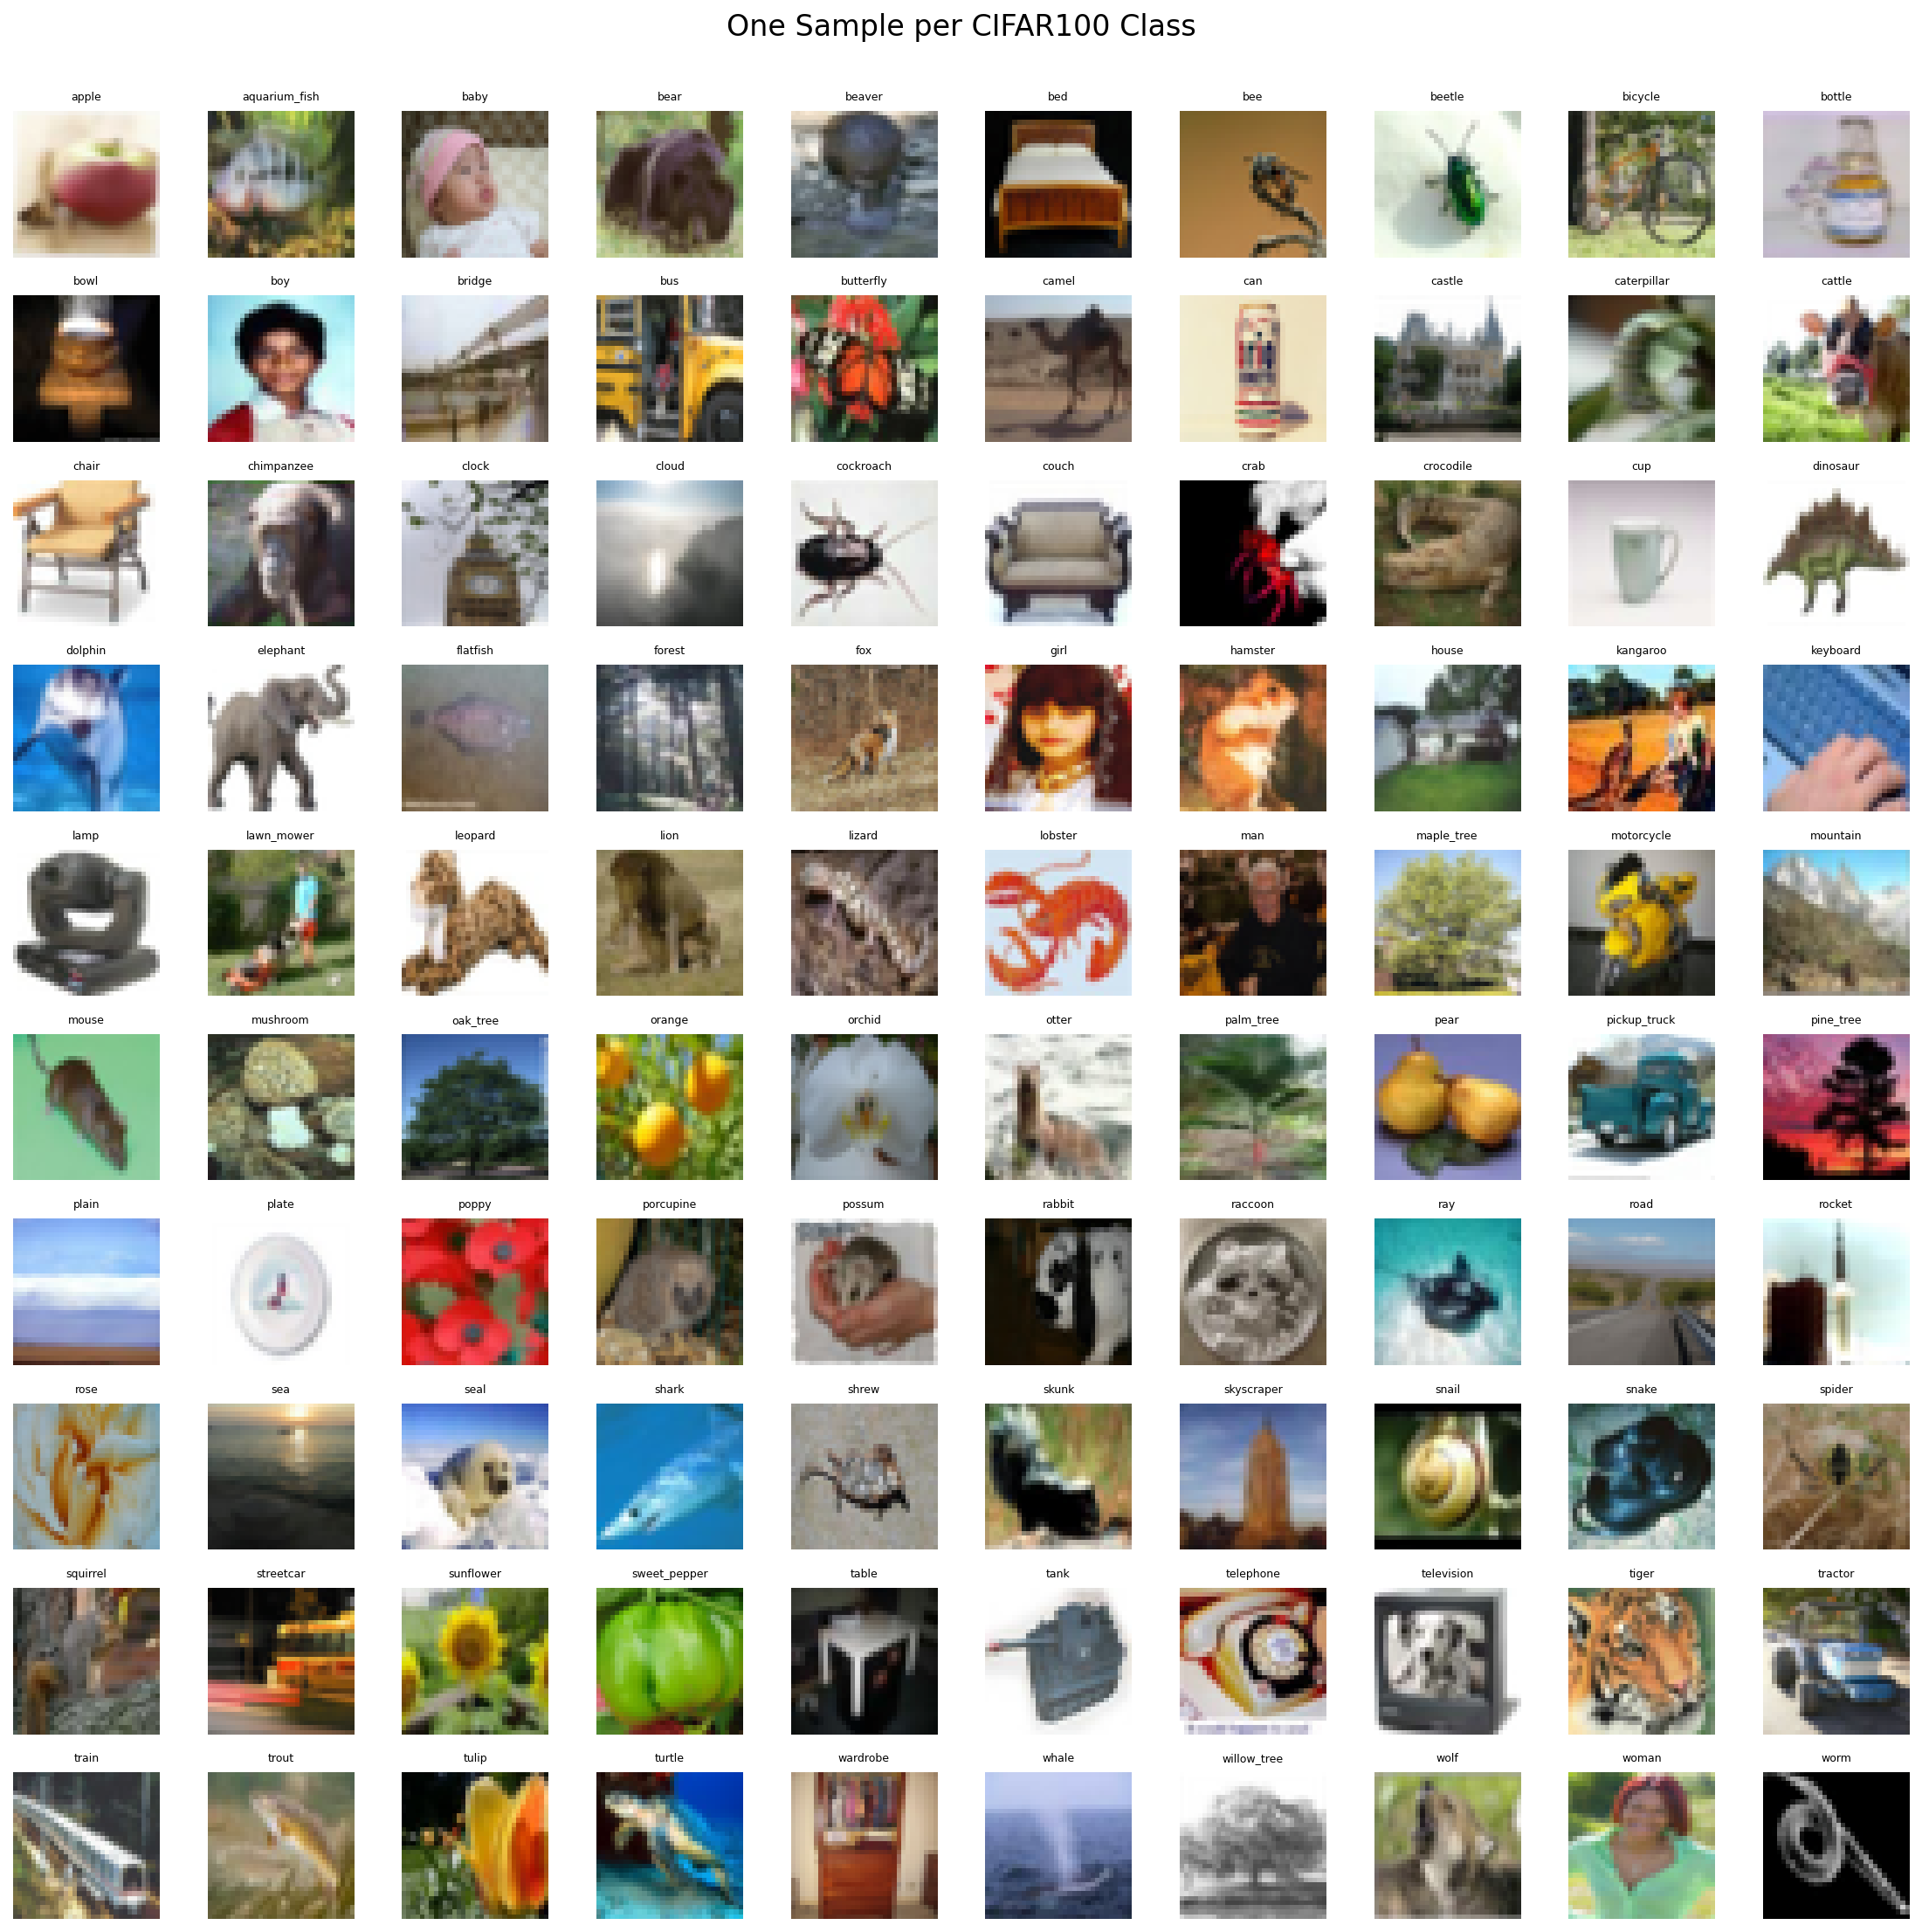

In [65]:
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# TODO: Find One Image from Each Class
class_to_image = {}
for img, label in cifar100_train:
    class_name = classes[label]
    if class_name not in class_to_image:
        class_to_image[class_name] = img
    if len(class_to_image) == len(classes):
        break

# TODO: Plot Images
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle("One Sample per CIFAR100 Class", fontsize=16)

for i, (class_name, img) in enumerate(sorted(class_to_image.items(), key=lambda x: classes.index(x[0]))):
    ax = axes[i // 10, i % 10]
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)  # Unnormalize
    img = img.clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_name, fontsize=6)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


### Modify Model

Change the final linear layer of the model according to the new number of classes And freeze all other layers.
- Do not forgot to move model to `device`

In [66]:
# Load Pretrained Model
model = MyCNN(feature_dim=256)  # make sure this gives output of 10 classes for now


state_dict = torch.load('net.pth', map_location=device)
model.load_state_dict(state_dict)  # can use strict=True now

model.fc_output = nn.Linear(256, 100)

# Freeze All Layers
for param in model.parameters():
    param.requires_grad = False


# Modify The Last Linear Layer
model.fc_output = nn.Linear(256, 100)  # Change output size from 10 to 100
model.fc_output.requires_grad = True  # Enable training for the new layer

# Move Model to Device
model = model.to(device)

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [67]:
# TODO: Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()

# Define Optimizer (only optimizing the new output layer)
optimizer = torch.optim.Adam(model.fc_output.parameters(), lr=0.001)

# Optional: Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

### Train

Train the Model (Only Last Layer)

In [68]:
# TODO: Train The Model

from torch.utils.data import DataLoader

# Define batch size
batch_size = 64

# Create DataLoader for training and testing datasets
train_loader_100 = DataLoader(cifar100_train, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_100 = DataLoader(cifar100_test, batch_size=batch_size, shuffle=False, num_workers=2)

num_epochs = 50  # You can adjust this
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm.tqdm(train_loader_100, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass through full model
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track stats
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Scheduler step
    scheduler.step()

    epoch_loss = running_loss / len(train_loader_100.dataset)
    epoch_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


Epoch 1/50: 100%|██████████| 782/782 [00:13<00:00, 56.87it/s]


Epoch [1/50], Loss: 3.5448, Accuracy: 15.74%


Epoch 2/50: 100%|██████████| 782/782 [00:13<00:00, 58.04it/s]


Epoch [2/50], Loss: 3.3140, Accuracy: 19.92%


Epoch 3/50: 100%|██████████| 782/782 [00:13<00:00, 57.34it/s]


...

Epoch [48/50], Loss: 2.9008, Accuracy: 28.01%


Epoch 49/50: 100%|██████████| 782/782 [00:13<00:00, 57.29it/s]


Epoch [49/50], Loss: 2.8992, Accuracy: 27.72%


Epoch 50/50: 100%|██████████| 782/782 [00:13<00:00, 56.84it/s]

Epoch [50/50], Loss: 2.9025, Accuracy: 27.90%


### Test

Evaluate the Model on CIFAR-100 Test Set. 40% accuracy is sufficient.


In [70]:
# TODO: Evaluate Model on CIFAR100
model.eval()
correct = 0
total = 0
running_loss = 0.0

with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader_100, desc="Evaluating on CIFAR-100 Test Set"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)

        # Track stats
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

# TODO: Print Accuracy
accuracy = 100. * correct / total
test_loss = running_loss / len(test_loader_100.dataset)

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

Evaluating on CIFAR-100 Test Set: 100%|██████████| 157/157 [00:02<00:00, 58.38it/s]

Test Loss: 2.6365, Test Accuracy: 34.19%


### Question
You might think that 40% accuracy is quite low. However, first of all, consider that the classification is done over 100 classes. The accuracy of a random model in this case is 1%. Also, we only changed one linear layer of the model, and the rest of the weights remained unchanged. What do you think is the reason the model can achieve a reasonably good generalization ability on a completely new dataset with just the change of one linear layer at the end?

Answer:
Since the model had already learned general features like edges, lines, and geometric shapes in the earlier layers, and these features are common across many images. When we only changed the last layer, the model still had access to these basic features. It could then use them to recognize more complex patterns like faces, objects, and other class-specific characteristics in the final layer. This allows the model to perform well on the new dataset even with just one layer changed!

### Visualize incorrectly predicted samples from testset

Visualize *10* random images from testset that are incorrectly predicted by the model

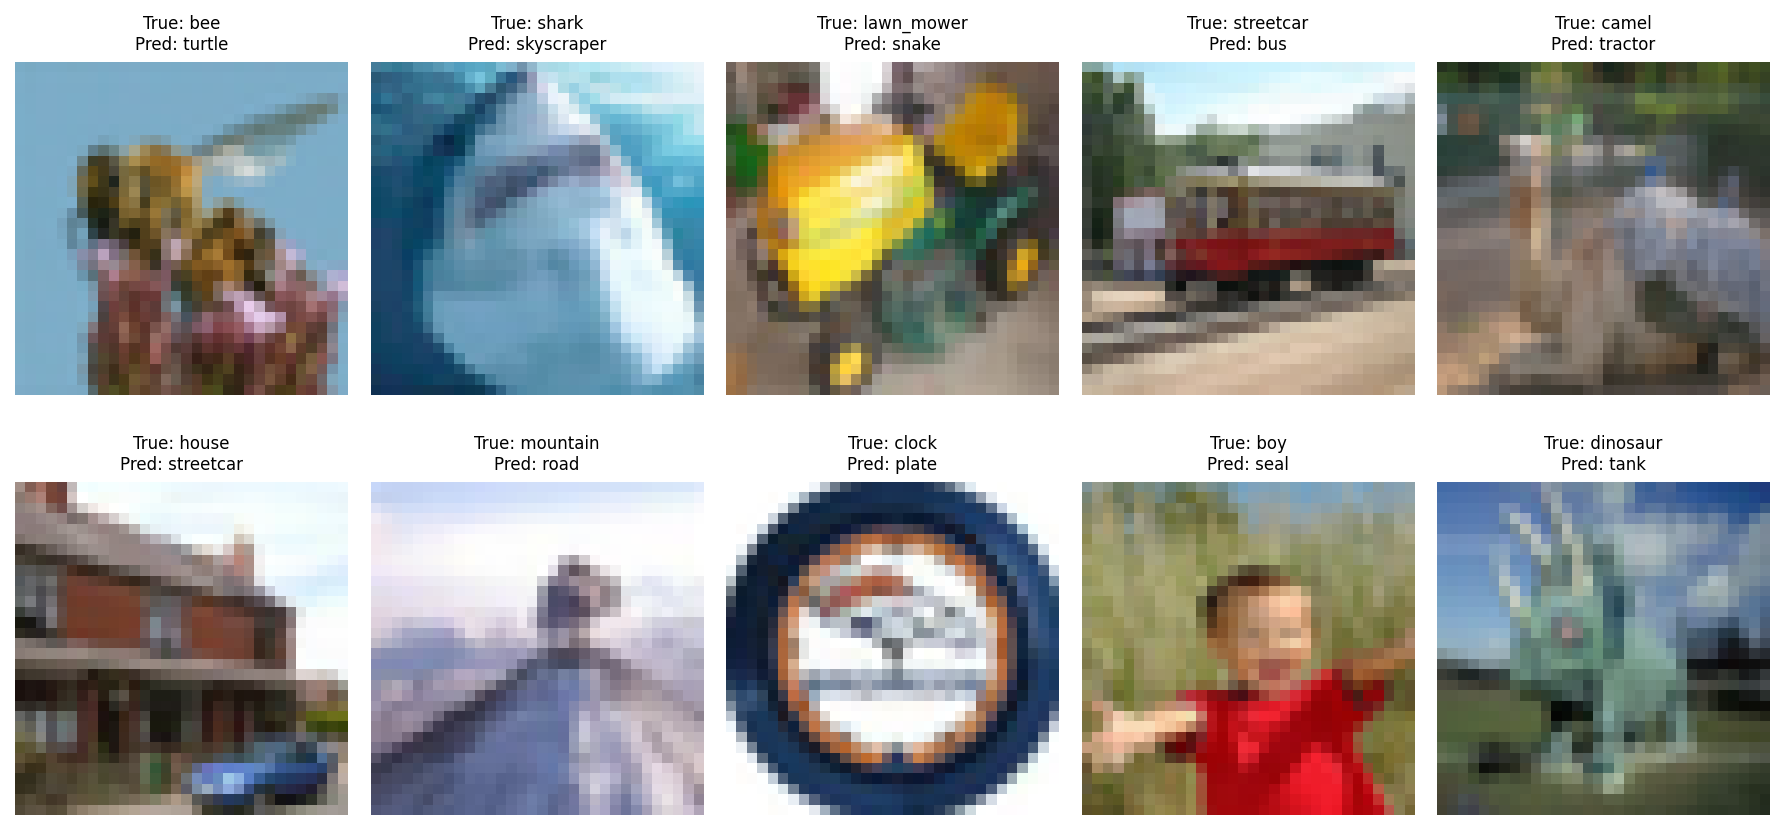

In [71]:
import random
import matplotlib.pyplot as plt
import torch

# Unnormalize function for CIFAR-100
def unnormalize(img_tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    return (img_tensor * std) + mean

# Lists to store incorrect predictions
incorrect_images = []
incorrect_labels = []
incorrect_preds = []

# Evaluate model on test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader_100:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs , _ = model(inputs)  # Assuming model returns logits directly
        preds = outputs.argmax(dim=1)

        for i in range(inputs.size(0)):
            if preds[i] != labels[i]:
                incorrect_images.append(inputs[i].cpu())
                incorrect_labels.append(labels[i].item())
                incorrect_preds.append(preds[i].item())

        if len(incorrect_images) >= 10:
            break

# Randomly select 10 incorrect samples to plot
random_indices = random.sample(range(len(incorrect_images)), 10)

# Plot the incorrect predictions
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    img = unnormalize(incorrect_images[idx]).clamp(0, 1)
    true_label = classes[incorrect_labels[idx]]
    pred_label = classes[incorrect_preds[idx]]

    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


### Plot accuracy for each class

Plot accuracy of model on testset for each class.

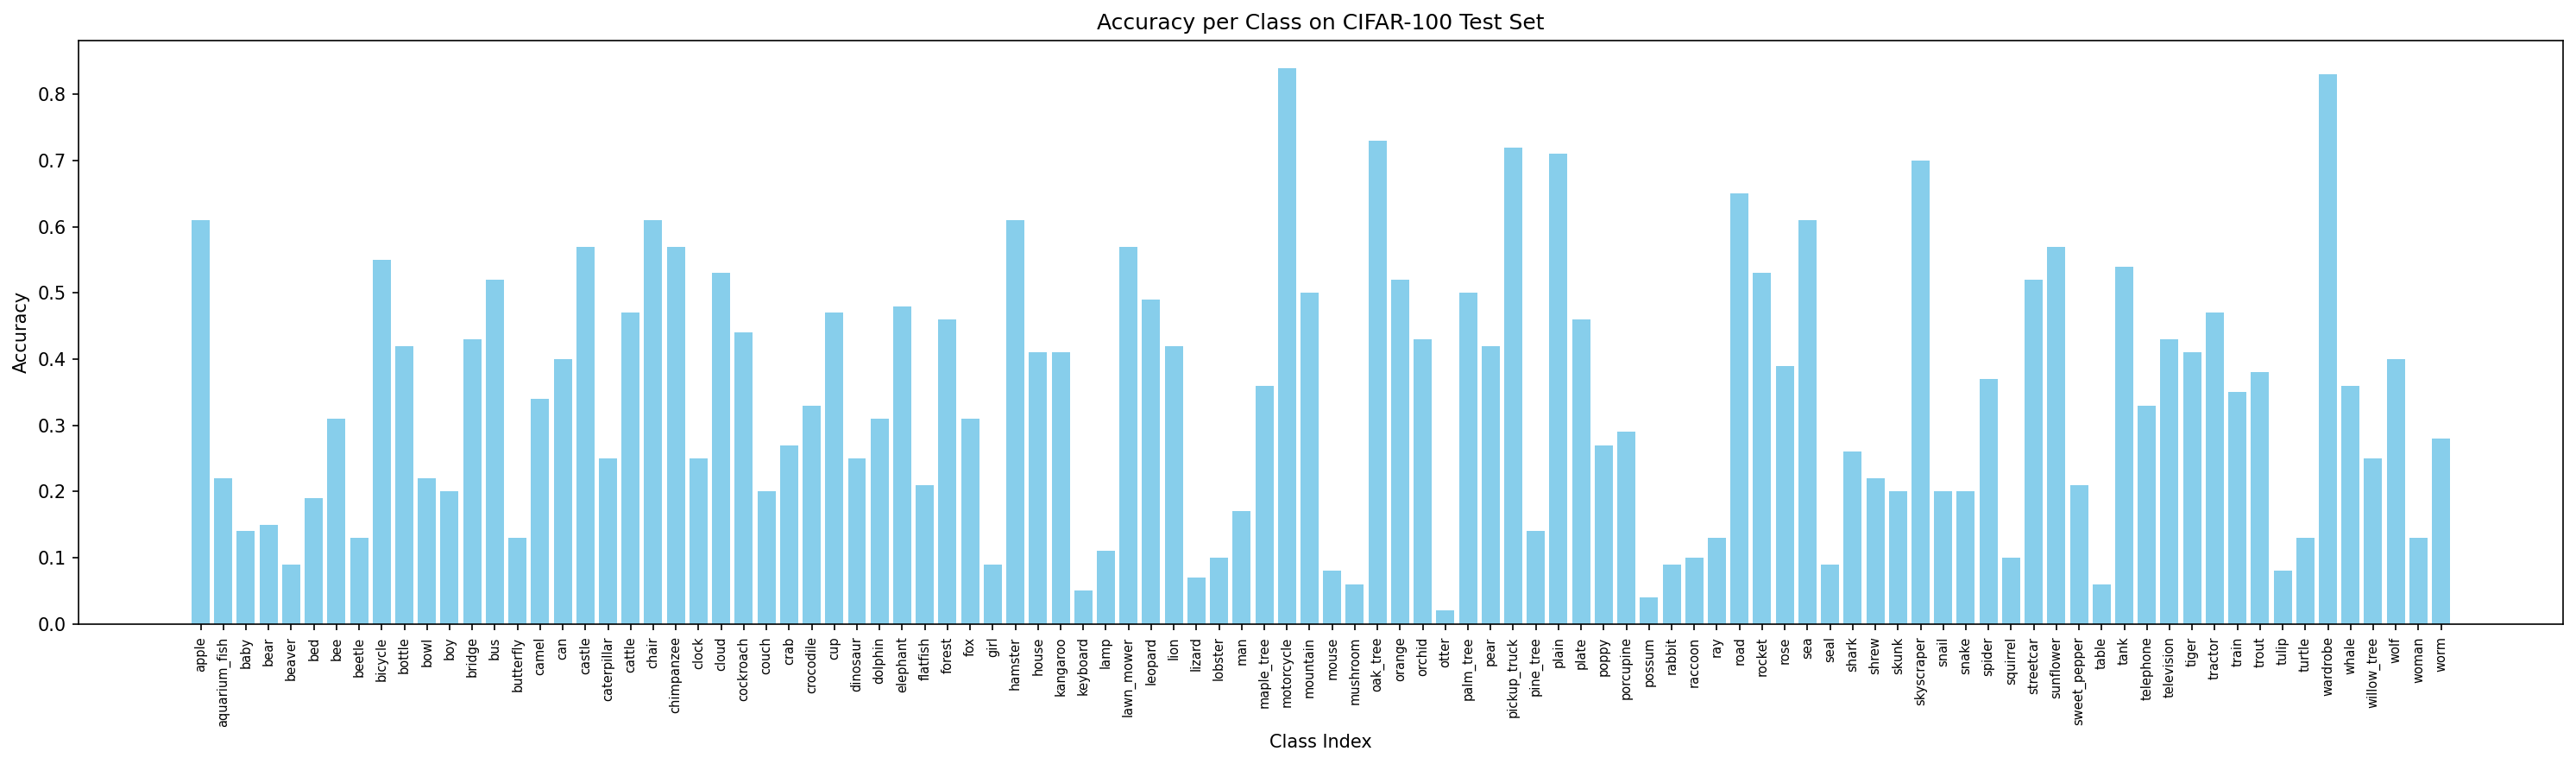

In [72]:
import torch
import matplotlib.pyplot as plt

# Initialize per-class counters
correct_per_class = [0] * 100
total_per_class = [0] * 100

# Evaluate the model
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader_100:  # Use correct test loader
        inputs, labels = inputs.to(device), labels.to(device)

        outputs , _ = model(inputs)  # Assuming model returns raw logits
        preds = outputs.argmax(dim=1)

        for label, pred in zip(labels, preds):
            label = label.item()
            total_per_class[label] += 1
            if pred.item() == label:
                correct_per_class[label] += 1

# Compute accuracy per class
class_accuracy = [correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0 for i in range(100)]

# Plotting
plt.figure(figsize=(20, 6))
bars = plt.bar(range(100), class_accuracy, color='skyblue')
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.title('Accuracy per Class on CIFAR-100 Test Set')

# Add class names as x-axis labels (rotated for readability)
plt.xticks(range(100), classes, rotation=90, fontsize=7)

plt.tight_layout()
plt.show()


### The classes with the best and worst accuracy

Based on the results from the previous section, obtain the 5 classes with the best accuracy and the 5 classes with the worst accuracy on the testset, and display one sample from each of them.

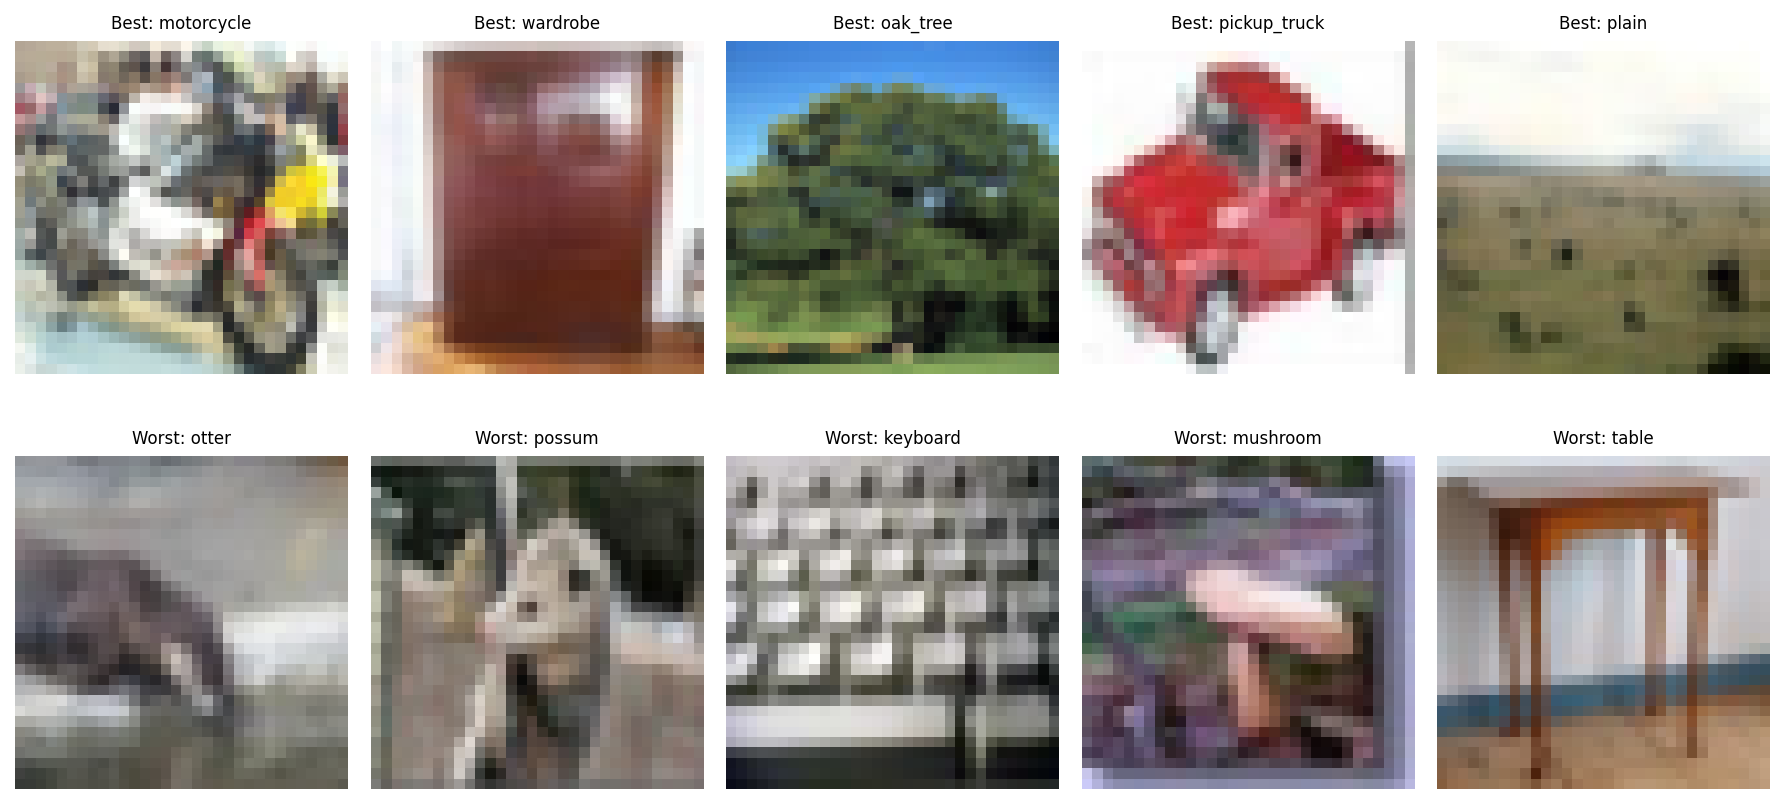

In [73]:
# Find top 5 best and worst performing class indices
best_classes = sorted(range(100), key=lambda x: class_accuracy[x], reverse=True)[:5]
worst_classes = sorted(range(100), key=lambda x: class_accuracy[x])[:5]

# Plot one image from each of these classes
plt.figure(figsize=(12, 6))

# Plot best performing classes (top row)
for i, cls in enumerate(best_classes):
    plt.subplot(2, 5, i + 1)
    for img, label in cifar100_test:  # Use dataset, not loader
        if label == cls:
            img = unnormalize(img).permute(1, 2, 0).numpy()
            plt.imshow(img)
            plt.title(f"Best: {classes[cls]}", fontsize=8)
            plt.axis('off')
            break

# Plot worst performing classes (bottom row)
for i, cls in enumerate(worst_classes):
    plt.subplot(2, 5, 5 + i + 1)
    for img, label in cifar100_test:
        if label == cls:
            img = unnormalize(img).permute(1, 2, 0).numpy()
            plt.imshow(img)
            plt.title(f"Worst: {classes[cls]}", fontsize=8)
            plt.axis('off')
            break

plt.tight_layout()
plt.show()


### Question
What do you think is the reason for the significant accuracy difference between different classes? What differences do you observe between the classes with the best and worst accuracy? Can you provide an analysis of the results and relate them to the model’s feature space?

Answer:
The significant accuracy difference between classes usually relates to differences in visual features, the number of samples, intra-class variability, and inter-class similarity. Classes with high accuracy typically have distinct features, uniform textures, and clear shapes (e.g., vehicles with a specific form), while classes with low accuracy may have high visual variability or be easily confused with other classes (such as animals with similar shapes or complex backgrounds). This suggests that the model has learned clear decision boundaries in the feature space for some classes, but for others, due to overlap or scatter in the data, it has struggled to define distinct boundaries. Therefore, the model’s weakness in distinguishing classes with less distinctive features or imbalanced data distribution leads to poor accuracy in those categories.








